# Chapter 24 Lab — A Mini-Multiverse of Analysis Pipelines (Python)

In this lab you will run a *mini-multiverse analysis*: one simulated fMRI "study" analyzed through every combination of a small grid of defensible pipeline choices. The arc has five steps:

1. **Simulate one study** — 24 subjects with a task effect in a small region, plus drift, autocorrelated noise, and motion-like spike artifacts
2. **Build the pipeline building blocks** — high-pass filtering, spatial smoothing, outlier (spike) handling, and autocorrelation correction
3. **Run the multiverse** — a factorial grid of 36 pipeline variants applied to the *same* data
4. **Visualize the "vibration of effects"** — the distribution of the group result across variants
5. **Draw a specification curve** — every variant's estimate, ordered, with the choices that produced it — and ask *which* choices matter

Because the data are simulated with known ground truth (the effect is real!), you can see directly how analytic flexibility alone — with no fraud and no p-hacking intent — spreads a single true effect across a range of "significant" and "non-significant" published-looking results.

**How to run this notebook.** Run it in your browser from the tutorial site, in Google Colab, or in a local Jupyter environment with numpy, scipy, pandas, and matplotlib installed. Each cell takes at most a few seconds. See the companion chapter page, [*Analysis Pipelines: Variations and Variability*](https://torwager.github.io/elements-of-fmri-tutorials/book/part4/ch24-analysis-pipelines-variations-and-variability), for the concepts behind the code.

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import gaussian_filter1d

np.set_printoptions(precision=3, suppress=True)
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.4.6 | pandas 3.0.5


## Step 1 — Simulate one study

We simulate a small but realistic single study:

- **24 subjects**, each with a 160-volume run (TR = 2 s, ~5.3 min)
- A strip of **40 voxels** (3 mm each) standing in for a slice through a region of interest
- A **blocked task regressor**: 4-s events every 24 s, convolved with a double-gamma HRF
- A **true positive effect** centered on voxel 20 (Gaussian spatial profile), with subject amplitudes drawn from a population distribution — so the *true* group effect is real but moderate, the situation where pipeline choices matter most. Our a-priori test is the task beta at the **peak voxel** (voxel 20), as if identified from prior studies
- Three realistic nuisance processes:
  - **slow scanner drift** (subject-specific low-frequency cosines)
  - **autocorrelated noise** (AR(1) with $\phi = 0.45$, where $\phi$ is the lag-1 autocorrelation coefficient)
  - **motion-like spikes**: 8 of the 24 subjects are "high-motion", with a handful of large global intensity spikes

Every pipeline variant will see *exactly the same data*.

In [2]:
rng = np.random.default_rng(24)    # seed, for reproducibility

# ---- geometry and timing -------------------------------------------------
TR, n_t = 2.0, 160                 # 160 volumes, ~5.3 min
n_v, vox_mm = 40, 3.0              # 40 voxels, 3 mm apart
n_sub = 24                         # number of subjects
frame_times = np.arange(n_t) * TR  # volume acquisition times (s)

# ---- task regressor: 4-s events every 24 s, double-gamma HRF -------------
def double_gamma_hrf(t):
    """Canonical double-gamma HRF (peak ~5 s, undershoot ~15 s)."""
    h = stats.gamma.pdf(t, 6, scale=1.0) - stats.gamma.pdf(t, 16, scale=1.0) / 6.0
    return h / h.max()

stim = np.zeros(n_t)
onsets = np.arange(12.0, n_t * TR - 24, 24.0)      # 13 events
for o in onsets:
    stim[(frame_times >= o) & (frame_times < o + 4.0)] = 1.0
hrf = double_gamma_hrf(np.arange(0, 32, TR))
task = np.convolve(stim, hrf)[:n_t]
task /= task.max()

# ---- true effect: Gaussian bump over voxels, variable across subjects ----
effect_profile = np.exp(-((np.arange(n_v) - 20.0) ** 2) / (2 * 4.0 ** 2))
sub_amp = rng.normal(0.22, 0.15, n_sub)            # population effect (mean 0.22, sd 0.15): real but moderate

# ---- simulate all subjects ----------------------------------------------
high_motion = np.zeros(n_sub, dtype=bool)
high_motion[rng.choice(n_sub, 8, replace=False)] = True   # 8 of 24 subjects are high-motion

data = np.zeros((n_sub, n_t, n_v))
phi_true = 0.45                    # AR(1) lag-1 autocorrelation of the noise
for s in range(n_sub):
    # AR(1) noise, independent across voxels
    innov = rng.standard_normal((n_t, n_v))
    noise = np.zeros((n_t, n_v))
    noise[0] = innov[0]
    for t in range(1, n_t):
        noise[t] = phi_true * noise[t - 1] + innov[t]

    # slow drift: two subject-specific low-frequency cosines (~355 s, ~188 s)
    tt = frame_times / frame_times[-1]
    drift = (rng.uniform(1.5, 5.0) * np.cos(2 * np.pi * 0.9 * tt + rng.uniform(0, 2 * np.pi))
             + rng.uniform(1.5, 5.0) * np.cos(2 * np.pi * 1.7 * tt + rng.uniform(0, 2 * np.pi)))
    drift = drift[:, None] * rng.normal(1.0, 0.15, n_v)[None, :]

    Y = 100.0 + sub_amp[s] * task[:, None] * effect_profile[None, :] + drift + noise

    if high_motion[s]:  # global motion-like spikes on a few frames
        frames = rng.choice(np.arange(5, n_t - 5), 8, replace=False)
        Y[frames, :] += (rng.uniform(8, 16, 8) * rng.choice([-1, 1], 8))[:, None]

    data[s] = Y

roi_vox = np.array([20])           # a-priori test: the true peak voxel
print(f"data: {data.shape} (subjects x time x voxels); "
      f"{high_motion.sum()} high-motion subjects")
print(f"true population effect: mean {sub_amp.mean():.2f}, sd {sub_amp.std():.2f} "
      f"(ideal group t ~ {sub_amp.mean() / sub_amp.std() * np.sqrt(n_sub):.1f})")

data: (24, 160, 40) (subjects x time x voxels); 8 high-motion subjects
true population effect: mean 0.21, sd 0.14 (ideal group t ~ 7.5)


Let's look at what one clean and one high-motion subject actually look like. Note the slow drift (comparable in size to the task effect!) and, for the high-motion subject, the abrupt global spikes.

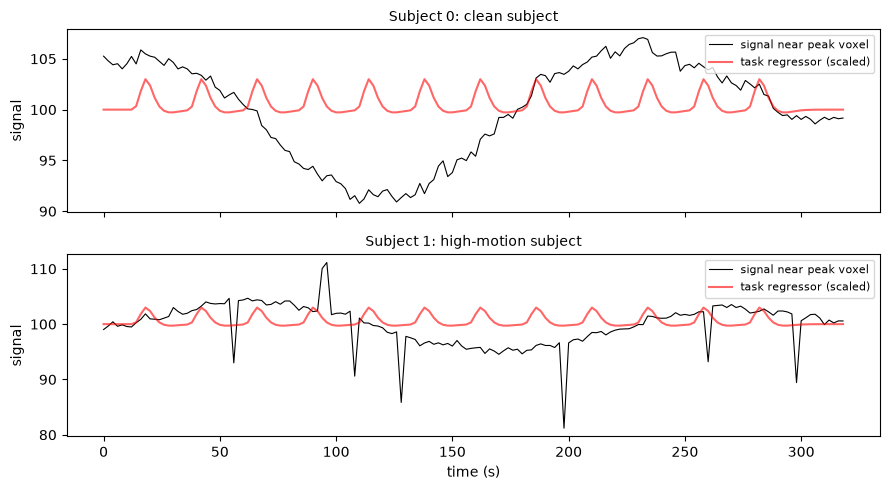

In [3]:
clean = np.where(~high_motion)[0][0]
spiky = np.where(high_motion)[0][0]

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
for ax, s, label in zip(axes, [clean, spiky], ["clean subject", "high-motion subject"]):
    ax.plot(frame_times, data[s][:, 18:23].mean(axis=1), "k-", lw=0.8,
            label="signal near peak voxel")
    ax.plot(frame_times, 100 + 3 * task, "r-", alpha=0.6, label="task regressor (scaled)")
    ax.set_ylabel("signal")
    ax.set_title(f"Subject {s}: {label}", fontsize=10)
    ax.legend(loc="upper right", fontsize=8)
axes[1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

## Step 2 — Pipeline building blocks

We now define the four **analytic choices** in our grid, each with defensible options a reasonable lab might pick:

| Factor | Options | Rationale |
|---|---|---|
| High-pass filter cutoff | none / 128 s / 64 s | drift removal via DCT (cosine) regressors, as in SPM |
| Spatial smoothing FWHM | 0 / 4 mm / 8 mm | Gaussian smoothing across voxels |
| Outlier handling | none / spike regressors | detect global spikes, add one regressor per bad frame |
| Autocorrelation correction | OLS / AR(1) prewhitening | Chapter 19's generalized least squares |

That is $3 \times 3 \times 2 \times 2 = 36$ pipelines. Each variant runs the same **summary-statistics analysis**: a first-level GLM per subject, then the task beta at the a-priori peak voxel is carried to a group one-sample t-test.

In [4]:
def dct_basis(n, TR, cutoff_s):
    """SPM-style discrete cosine drift regressors for periods > cutoff_s."""
    order = int(np.floor(2 * n * TR / cutoff_s))
    k = np.arange(1, order + 1)
    t = np.arange(n)
    return np.cos(np.pi / n * np.outer(t + 0.5, k))

def find_spike_frames(Y, z_thresh=5.0):
    """Flag frames with abrupt global intensity jumps (robust z on the
    frame-to-frame difference of the global mean signal)."""
    g = Y.mean(axis=1)
    dg = np.abs(np.diff(g, prepend=g[0]))
    mad = np.median(np.abs(dg - np.median(dg))) * 1.4826 + 1e-12
    return np.where((dg - np.median(dg)) / mad > z_thresh)[0]

def first_level_roi_beta(Y, hp_cutoff, fwhm_mm, despike, ar1):
    """One subject through one pipeline variant -> mean task beta in the ROI."""
    if fwhm_mm > 0:                                       # spatial smoothing
        Y = gaussian_filter1d(Y, fwhm_mm / 2.355 / vox_mm, axis=1)

    cols = [task, np.ones(n_t)]                            # task + intercept
    if hp_cutoff is not None:                              # high-pass filter
        cols.append(dct_basis(n_t, TR, hp_cutoff))
    if despike:                                            # spike regressors
        for f in find_spike_frames(Y):
            spike = np.zeros(n_t); spike[f] = 1.0
            cols.append(spike)
    X = np.column_stack(cols)

    B = np.linalg.lstsq(X, Y, rcond=None)[0]               # OLS fit
    if ar1:                                                # AR(1) prewhitening
        R = Y - X @ B
        phi = np.mean(np.sum(R[1:] * R[:-1], axis=0) /
                      np.sum(R[:-1] ** 2, axis=0))
        Yw, Xw = Y[1:] - phi * Y[:-1], X[1:] - phi * X[:-1]
        B = np.linalg.lstsq(Xw, Yw, rcond=None)[0]

    return B[0, roi_vox].mean()                            # task beta, ROI mean

# quick check: the spike detector on our high-motion subject
print(f"subject {spiky}: flagged frames {find_spike_frames(data[spiky])}")

subject 1: flagged frames [ 28  29  47  49  54  55  64  65  99 100 130 131 149 150]


## Step 3 — Run the multiverse

Now the heart of the lab: loop over the full factorial grid, apply each pipeline to all 24 subjects, and record the group-level result. Every row of the results table is one complete, publishable-looking analysis of the same data.

In [5]:
hp_opts      = [None, 128, 64]        # high-pass cutoffs (s); None = no filtering
fwhm_opts    = [0, 4, 8]              # smoothing FWHM (mm); 0 = none
despike_opts = [False, True]          # spike regressors?
ar1_opts     = [False, True]          # AR(1) prewhitening?

rows = []                             # one result dict per pipeline variant
for hp, fwhm, despike, ar1 in itertools.product(
        hp_opts, fwhm_opts, despike_opts, ar1_opts):
    betas = np.array([first_level_roi_beta(data[s], hp, fwhm, despike, ar1)
                      for s in range(n_sub)])
    t, p = stats.ttest_1samp(betas, 0.0)
    rows.append({"hp": "none" if hp is None else f"{hp} s",
                 "fwhm": f"{fwhm} mm", "despike": despike, "ar1": ar1,
                 "mean_beta": betas.mean(),
                 "sem": betas.std(ddof=1) / np.sqrt(n_sub),
                 "t": t, "p": p})

results = pd.DataFrame(rows)
results["significant"] = results["p"] < 0.05

print(f"{len(results)} pipeline variants; "
      f"{results['significant'].sum()} significant at p < .05 "
      f"({100 * results['significant'].mean():.0f}%)")
print(f"group t range: {results['t'].min():.2f} to {results['t'].max():.2f}")
results.round(3).head(8)

36 pipeline variants; 9 significant at p < .05 (25%)
group t range: 0.79 to 3.00


,hp,fwhm,despike,ar1,mean_beta,sem,t,p,significant
0,none,0 mm,False,False,0.321,0.180,1.784,0.088,False
1,none,0 mm,False,True,0.162,0.132,1.227,0.232,False
2,none,0 mm,True,False,0.138,0.174,0.788,0.439,False
3,none,0 mm,True,True,0.129,0.089,1.451,0.160,False
4,none,4 mm,False,False,0.315,0.174,1.809,0.084,False
5,none,4 mm,False,True,0.166,0.120,1.386,0.179,False
6,none,4 mm,True,False,0.132,0.167,0.794,0.435,False
7,none,4 mm,True,True,0.142,0.073,1.946,0.064,False


One dataset. One (real!) effect. And depending on four defensible preprocessing choices, the study either "works" or "fails". This is the situation the NARPS study (Botvinik-Nezer et al., 2020) documented in the wild: 70 teams, one dataset, and only 37% of teams declaring the vmPFC gain effect significant.

## Step 4 — The vibration of effects

Plot the distribution of the group t-statistic across all 36 variants — sometimes called the *vibration of effects*. The dashed line is the significance threshold: variants to its right get published as "activation", variants to its left as "no effect", yet all describe the same data.

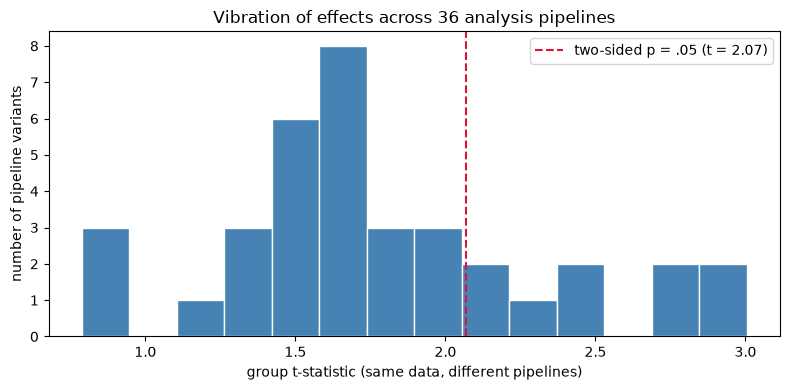

In [6]:
t_crit = stats.t.ppf(0.975, n_sub - 1)   # two-sided p = .05 critical t, df = n_sub - 1

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(results["t"], bins=14, color="steelblue", edgecolor="white")
ax.axvline(t_crit, color="crimson", ls="--", lw=1.5,
           label=f"two-sided p = .05 (t = {t_crit:.2f})")
ax.set_xlabel("group t-statistic (same data, different pipelines)")
ax.set_ylabel("number of pipeline variants")
ax.set_title("Vibration of effects across 36 analysis pipelines")
ax.legend()
plt.tight_layout()
plt.show()

## Step 5 — The specification curve

A **specification-curve** (multiverse) plot shows every variant at once: the top panel orders the 36 group estimates from smallest to largest with 95% confidence intervals; the bottom panel shows, for each variant, which option was chosen for each factor. Reading vertically links an estimate to the exact pipeline that produced it; reading a bottom row horizontally shows whether an option systematically pushes estimates up or down.

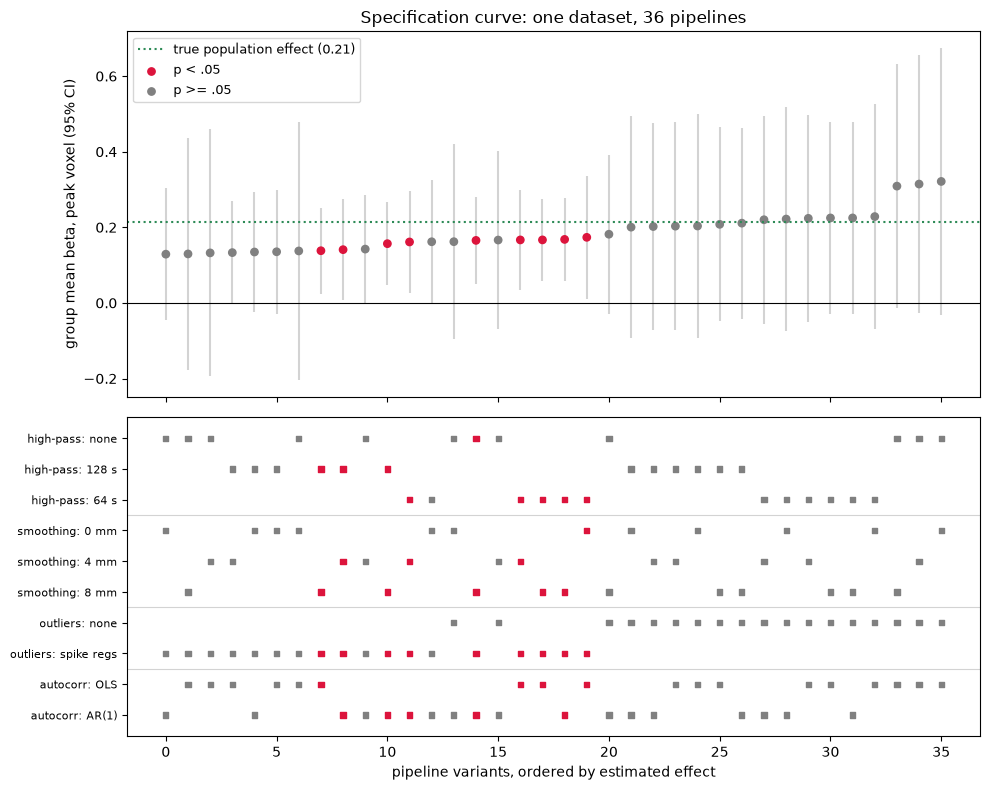

In [7]:
res = results.sort_values("mean_beta").reset_index(drop=True)
x = np.arange(len(res))
sig_col = np.where(res["significant"], "crimson", "gray")   # red = significant

spec_rows = [("high-pass: none", res["hp"] == "none"),
             ("high-pass: 128 s", res["hp"] == "128 s"),
             ("high-pass: 64 s", res["hp"] == "64 s"),
             ("smoothing: 0 mm", res["fwhm"] == "0 mm"),
             ("smoothing: 4 mm", res["fwhm"] == "4 mm"),
             ("smoothing: 8 mm", res["fwhm"] == "8 mm"),
             ("outliers: none", ~res["despike"]),
             ("outliers: spike regs", res["despike"]),
             ("autocorr: OLS", ~res["ar1"]),
             ("autocorr: AR(1)", res["ar1"])]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                               height_ratios=[1.6, 1.4])
ax1.axhline(0, color="k", lw=0.8)
ax1.errorbar(x, res["mean_beta"], yerr=1.96 * res["sem"], fmt="none",
             ecolor="lightgray", elinewidth=1.5, zorder=1)
ax1.scatter(x, res["mean_beta"], c=sig_col, s=28, zorder=2)
ax1.axhline(sub_amp.mean(), color="seagreen", ls=":", lw=1.5,
            label=f"true population effect ({sub_amp.mean():.2f})")
ax1.scatter([], [], c="crimson", s=28, label="p < .05")
ax1.scatter([], [], c="gray", s=28, label="p >= .05")
ax1.set_ylabel("group mean beta, peak voxel (95% CI)")
ax1.set_title("Specification curve: one dataset, 36 pipelines")
ax1.legend(loc="upper left", fontsize=9)

for i, (label, mask) in enumerate(spec_rows):
    yy = len(spec_rows) - 1 - i
    ax2.scatter(x[mask.to_numpy()], np.full(mask.sum(), yy), s=14,
                c=sig_col[mask.to_numpy()], marker="s")
ax2.set_yticks(np.arange(len(spec_rows)))
ax2.set_yticklabels([r[0] for r in reversed(spec_rows)], fontsize=8)
for y in [1.5, 3.5, 6.5]:
    ax2.axhline(y, color="lightgray", lw=0.8)
ax2.set_xlabel("pipeline variants, ordered by estimated effect")
ax2.set_ylim(-0.7, len(spec_rows) - 0.3)
plt.tight_layout()
plt.show()

## Step 6 — Which choices matter?

The specification curve suggests that some rows cluster at one end (that choice *matters*) while others are evenly spread (that choice barely moves the group result). Averaging the group t within each factor level makes this quantitative.

In [8]:
for factor in ["hp", "fwhm", "despike", "ar1"]:
    summary = results.groupby(factor)[["t", "mean_beta"]].mean().round(2)
    summary["% significant"] = (results.groupby(factor)["significant"]
                                .mean() * 100).round(0)
    print(f"--- {factor} ---")
    print(summary, "\n")

--- hp ---
          t  mean_beta  % significant
hp                                   
128 s  1.77       0.17           25.0
64 s   2.04       0.20           42.0
none   1.53       0.19            8.0 

--- fwhm ---
         t  mean_beta  % significant
fwhm                                
0 mm  1.52       0.18            8.0
4 mm  1.73       0.18           25.0
8 mm  2.09       0.19           42.0 

--- despike ---
            t  mean_beta  % significant
despike                                
False    1.57       0.22            0.0
True     2.00       0.15           50.0 

--- ar1 ---
          t  mean_beta  % significant
ar1                                  
False  1.70       0.20           22.0
True   1.87       0.18           28.0 



A typical pattern (your exact numbers depend on the simulation seed):

- **High-pass filtering** matters a lot here: unmodeled drift inflates first-level error and biases some subjects' betas, dragging the group t down.
- **Spatial smoothing** matters: averaging over voxels suppresses independent noise while (with a broad true effect) preserving signal.
- **Spike handling** helps mainly the 8 high-motion subjects, tightening the group estimate.
- **AR(1) prewhitening changes almost nothing** — an important lesson! In a summary-statistics group analysis, first-level autocorrelation mostly affects first-level *standard errors*, not the betas carried to the group level. Some celebrated pipeline choices are near-irrelevant for a given question, while humble ones (drift, outliers) dominate.

## Wrap-up: what to do about it

This mini-multiverse is tiny — Carp (2012) counted 34,560 plausible pipelines, and the real "garden of forking paths" is larger still. Three habits keep analytic flexibility from becoming silent multiplicity:

1. **Decide the pipeline before seeing the results** — preregister it, or adopt a standardized, community-tested pipeline (e.g., fMRIPrep on BIDS-formatted data) and report deviations.
2. **Report the multiverse, not the best branch.** If you explored variants, show the distribution (as above), not the single pipeline that "worked".
3. **Share code, data, and unthresholded maps** so others can rerun your pipeline — and their own — on your data.

**Exercises.** (a) Re-run the simulation with `sub_amp = rng.normal(0.6, 0.15, n_sub)` (a strong effect) — what happens to the fraction of significant variants, and why? (b) Add a fourth high-pass option (32 s) — aggressive filtering that starts to remove task frequencies. (c) Change `roi_vox` to `np.array([3])`, far from the true effect, and check how often the 36 variants produce a "significant" result when you get to pick the best one.